In [1]:
# Mount Drive & Extract Dataset

import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/DFU Dataset.zip"
extract_path = "/content/DFU_Dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['DFU Dataset']


In [2]:
# Import libraries

import os
import cv2
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Config Setup

DATASET = "/content/DFU_Dataset/DFU Dataset"

train_dir = os.path.join(DATASET, "train")
val_dir   = os.path.join(DATASET, "val")
test_dir  = os.path.join(DATASET, "test")

IMG_SIZE = (300, 300)
BATCH_SIZE = 32

In [4]:
# Augmentation & Generators

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3295 images belonging to 3 classes.
Found 837 images belonging to 3 classes.
Found 1033 images belonging to 3 classes.


In [5]:
# Class Weights

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.3185274109643859), 1: np.float64(0.8907812922411462), 2: np.float64(0.8936804990507188)}


In [6]:
# Build Model

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,705,650 (44.65 MB)

 Trainable params: 920,579 (3.51 MB)

 Non-trainable params: 10,785,071 (41.14 MB)

In [7]:
# Callbacks

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

In [8]:
# Training

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9175 - loss: 0.2282 - val_accuracy: 0.9725 - val_loss: 0.0798 - learning_rate: 0.0010
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 83s 804ms/step - accuracy: 0.9660 - loss: 0.1147 - val_accuracy: 0.9916 - val_loss: 0.0332 - learning_rate: 0.0010
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 79s 770ms/step - accuracy: 0.9766 - loss: 0.0787 - val_accuracy: 0.9952 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 79s 767ms/step - accuracy: 0.9812 - loss: 0.0622 - val_accuracy: 0.9857 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 760ms/step - accuracy: 0.9827 - loss: 0.0591 - val_accuracy: 0.9976 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 755ms/step - accuracy: 0.9785 - loss: 0.0614 - val_accuracy: 0.9606 - val_loss: 0.1072 - learning_rate: 0.0010
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 77s 746ms/step - accuracy: 0.978

In [9]:
# Fine-Tune

for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Training - 2

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9445 - loss: 0.1687 - val_accuracy: 0.9928 - val_loss: 0.0199 - learning_rate: 1.0000e-05
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 750ms/step - accuracy: 0.9648 - loss: 0.1138 - val_accuracy: 0.9916 - val_loss: 0.0258 - learning_rate: 1.0000e-05
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 762ms/step - accuracy: 0.9693 - loss: 0.0971 - val_accuracy: 0.9916 - val_loss: 0.0229 - learning_rate: 1.0000e-05
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 753ms/step - accuracy: 0.9712 - loss: 0.0769 - val_accuracy: 0.9916 - val_loss: 0.0217 - learning_rate: 3.0000e-06
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 80s 778ms/step - accuracy: 0.9775 - loss: 0.0658 - val_accuracy: 0.9916 - val_loss: 0.0203 - learning_rate: 3.0000e-06


In [11]:
# Evaluation

loss, acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 650ms/step - accuracy: 0.9835 - loss: 0.0544
✅ Test Accuracy: 98.35%


33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 474ms/step

Classification Report:

                     precision    recall  f1-score   support

Diabetic Foot Ulcer       0.96      1.00      0.98       261
            Healthy       0.99      1.00      0.99       387
              Wound       0.99      0.96      0.98       385

           accuracy                           0.98      1033
          macro avg       0.98      0.98      0.98      1033
       weighted avg       0.98      0.98      0.98      1033



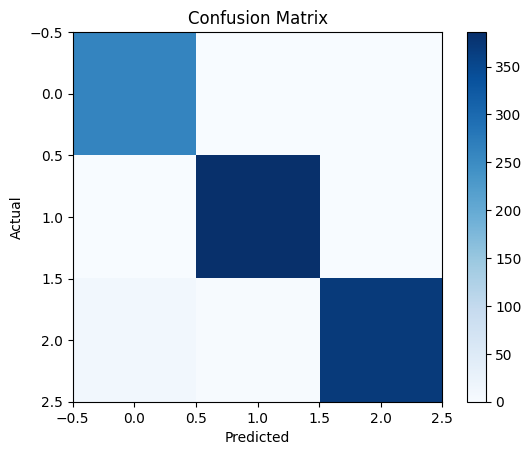

In [12]:
# Confusion Matrix

test_gen.reset()
pred = model.predict(test_gen)

y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

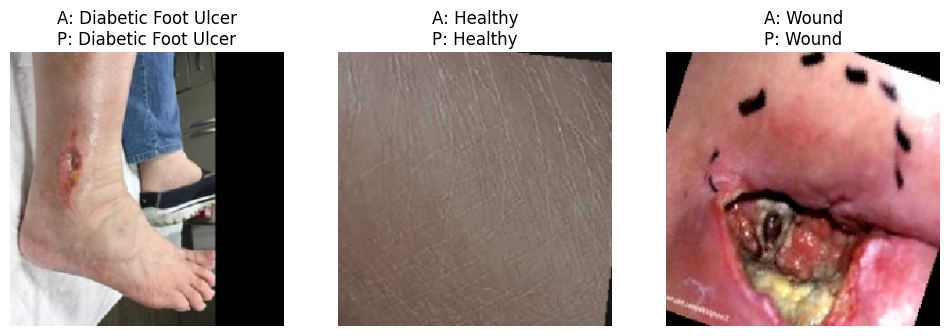

In [13]:
# Test: 1 Image Per Class

CLASS_NAMES = list(test_gen.class_indices.keys())

plt.figure(figsize=(12,4))

for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(test_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = CLASS_NAMES[np.argmax(pred)]

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"A: {cls}\nP: {pred_class}")
    plt.axis("off")

plt.show()

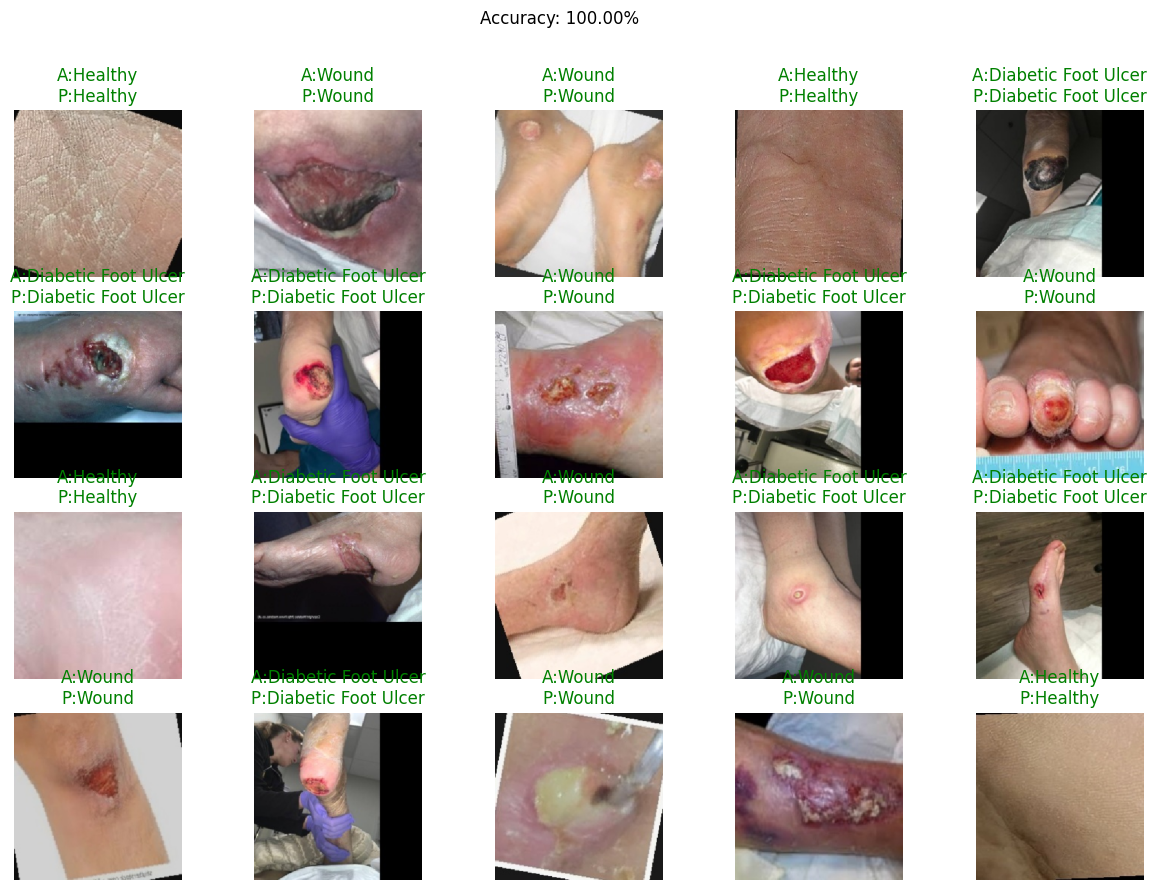

In [14]:
# Random Test on 20 Images

all_images = []
all_labels = []

for cls in CLASS_NAMES:
    folder = os.path.join(test_dir, cls)
    for img_name in os.listdir(folder):
        all_images.append(os.path.join(folder, img_name))
        all_labels.append(cls)

idx = random.sample(range(len(all_images)), 20)

plt.figure(figsize=(15,10))
correct = 0

for i, id in enumerate(idx):
    img_path = all_images[id]
    true_label = all_labels[id]

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = CLASS_NAMES[np.argmax(pred)]

    if pred_class == true_label:
        correct += 1

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(f"A:{true_label}\nP:{pred_class}",
              color="green" if pred_class==true_label else "red")
    plt.axis("off")

plt.suptitle(f"Accuracy: {(correct/20)*100:.2f}%")
plt.show()

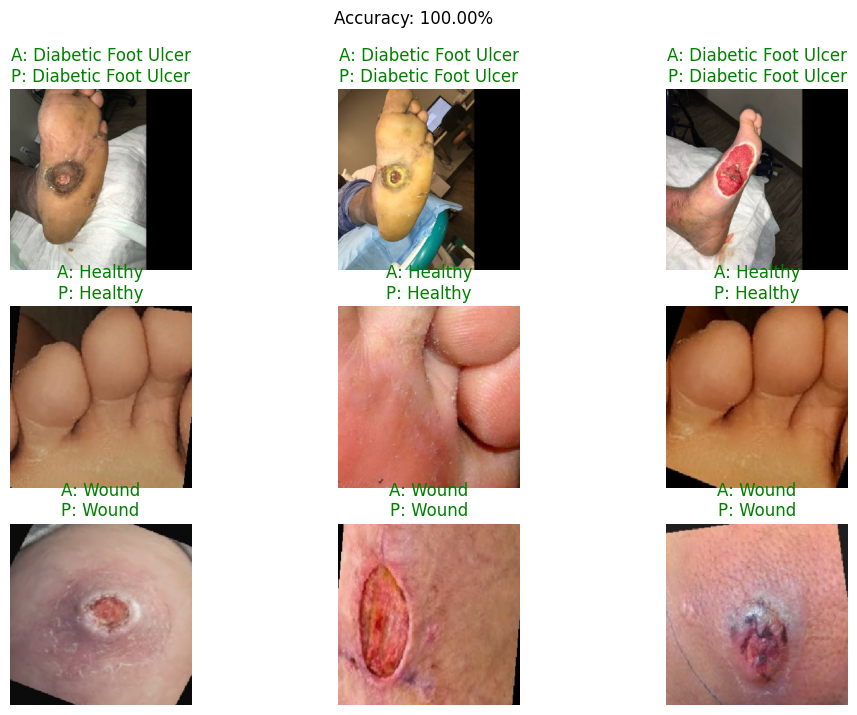

In [15]:
# Real World Testing

test_path = "/content/drive/MyDrive/Colab Notebooks/Testing DFU"

images = sorted(os.listdir(test_path))

plt.figure(figsize=(12,8))

correct = 0

for i, img_name in enumerate(images):
    img_path = os.path.join(test_path, img_name)

    if "Diabetic" in img_name:
        actual = "Diabetic Foot Ulcer"
    elif "Healthy" in img_name:
        actual = "Healthy"
    else:
        actual = "Wound"

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = CLASS_NAMES[np.argmax(pred)]

    if actual == pred_class:
        correct += 1

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"A: {actual}\nP: {pred_class}", color='green' if actual==pred_class else 'red')
    plt.axis("off")

accuracy = correct / len(images) * 100
plt.suptitle(f"Accuracy: {accuracy:.2f}%")
plt.show()

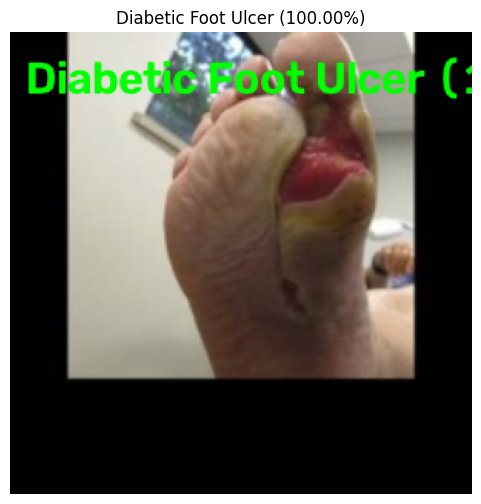

In [16]:
# OpenCV Detection

classes = CLASS_NAMES

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, IMG_SIZE)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(2.0, (8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    enhanced = preprocess_input(enhanced)
    enhanced = np.expand_dims(enhanced, axis=0)

    return img, enhanced

def detect_ulcer(path):
    original, processed = preprocess_image(path)

    pred = model.predict(processed, verbose=0)
    label = classes[np.argmax(pred)]
    conf = np.max(pred) * 100

    cv2.putText(original, f"{label} ({conf:.2f}%)",
                (10,40), cv2.FONT_HERSHEY_SIMPLEX,
                1,(0,255,0),2)

    img_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(f"{label} ({conf:.2f}%)")
    plt.axis("off")
    plt.show()

# Update this path to a sample image inside your extracted dataset
detect_ulcer("/content/DFU_Dataset/DFU Dataset/test/Diabetic Foot Ulcer/DFU (112).jpg")